<a href="https://colab.research.google.com/github/Ivan35-arch/Ivan35-arch/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Ivan35-arch/chatbot_class.git

Cloning into 'chatbot_class'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 6 (delta 0), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 9.59 KiB | 9.59 MiB/s, done.


In [2]:
# Install required packages (uncomment if not already installed)
# !pip install nltk scikit-learn joblib requests beautifulsoup4 matplotlib seaborn

import subprocess, sys
pkgs = ["nltk", "scikit-learn", "joblib", "requests", "beautifulsoup4",
        "matplotlib", "seaborn", "nbformat"]
for pkg in pkgs:
    try:
        __import__(pkg.replace("-", "_").split("==")[0])
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages available ✓")


All packages available ✓


In [3]:
import json
import random
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.stem import PorterStemmer

from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import joblib

# Download required NLTK models
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

stemmer = PorterStemmer()
print("Imports complete ✓")


Imports complete ✓


In [6]:
# Load the intents dataset
BASE_DIR = os.getcwd()
INTENTS_PATH = os.path.join(BASE_DIR, "chatbot_class", "intents.json")

with open(INTENTS_PATH, "r", encoding="utf-8") as f:
    intents_data = json.load(f)

print(f"Total intents (categories): {len(intents_data['intents'])}")
print()
for intent in intents_data["intents"]:
    print(f"  {intent['tag']:<30}  {len(intent['patterns'])} patterns, "
          f"{len(intent['responses'])} responses")


Total intents (categories): 15

  greeting                        15 patterns, 3 responses
  goodbye                         15 patterns, 3 responses
  admissions_requirements         16 patterns, 3 responses
  admissions_deadlines            16 patterns, 3 responses
  undergraduate_programmes        16 patterns, 3 responses
  postgraduate_programmes         16 patterns, 3 responses
  tuition_fees                    16 patterns, 3 responses
  fee_payment                     16 patterns, 3 responses
  academic_calendar               16 patterns, 3 responses
  exam_timetables                 16 patterns, 3 responses
  campus_location                 16 patterns, 3 responses
  contacts                        16 patterns, 3 responses
  student_services                16 patterns, 3 responses
  scholarships                    16 patterns, 3 responses
  online_learning                 16 patterns, 3 responses


In [5]:
INTENTS_PATH = os.path.join(BASE_DIR, "chatbot_class", "intents.json")

In [7]:
# Display 3 sample patterns for each intent
for intent in intents_data["intents"]:
    samples = random.sample(intent["patterns"], min(3, len(intent["patterns"])))
    print(f"[{intent['tag']}]")
    for s in samples:
        print(f"   • {s}")
    print()


[greeting]
   • Hi bot
   • Good morning
   • Hi there

[goodbye]
   • Thanks bye
   • Thanks, that's all
   • Exit

[admissions_requirements]
   • Can I join KCAU with a C plain?
   • What are the admission requirements?
   • KCSE minimum grade for KCAU

[admissions_deadlines]
   • When is the application deadline?
   • Application closing
   • When should I submit my application?

[undergraduate_programmes]
   • Bachelor's degrees available
   • List of degree programmes at KCAU
   • Which faculties does KCAU have

[postgraduate_programmes]
   • Does KCAU have a Masters programme?
   • MBA details KCAU
   • Postgrad options KCAU

[tuition_fees]
   • How much is tuition at KCAU?
   • How much does KCAU charge per semester?
   • Fee schedule KCAU

[fee_payment]
   • M-Pesa payment for KCAU fees
   • Fee deadline
   • Fee balance enquiry

[academic_calendar]
   • End of semester dates
   • When is the new semester?
   • When does the semester start?

[exam_timetables]
   • Exam timetabl

In [8]:
def tokenize_and_stem(sentence: str) -> list:
    """Lowercase, tokenise, remove punctuation, stem each token."""
    tokens = nltk.word_tokenize(sentence.lower())
    return [stemmer.stem(t) for t in tokens if t.isalpha()]

# Quick demonstration
sample_sentence = "What are the admission requirements for undergraduate students?"
print(f"Input   : {sample_sentence}")
print(f"Stemmed : {tokenize_and_stem(sample_sentence)}")


Input   : What are the admission requirements for undergraduate students?
Stemmed : ['what', 'are', 'the', 'admiss', 'requir', 'for', 'undergradu', 'student']


In [9]:
all_words   = []   # flat list of all stemmed tokens across all patterns
classes     = []   # unique intent tags
documents   = []   # list of (stemmed_tokens, tag) pairs

for intent in intents_data["intents"]:
    tag = intent["tag"]
    if tag not in classes:
        classes.append(tag)
    for pattern in intent["patterns"]:
        tokens = tokenize_and_stem(pattern)
        all_words.extend(tokens)
        documents.append((tokens, tag))

# Deduplicate and sort
vocabulary = sorted(set(all_words))
classes    = sorted(classes)

print(f"Vocabulary size       : {len(vocabulary)}")
print(f"Number of intents     : {len(classes)}")
print(f"Total training samples: {len(documents)}")
print(f"\nFirst 20 vocabulary words: {vocabulary[:20]}")


Vocabulary size       : 219
Number of intents     : 15
Total training samples: 238

First 20 vocabulary words: ['a', 'academ', 'access', 'accommod', 'account', 'accredit', 'address', 'admiss', 'admit', 'affair', 'aid', 'all', 'annual', 'appli', 'applic', 'are', 'area', 'at', 'avail', 'bachelor']


In [10]:
def bag_of_words(tokens: list, vocab: list) -> np.ndarray:
    """Convert a list of stemmed tokens into a binary BoW vector."""
    return np.array([1 if w in tokens else 0 for w in vocab], dtype=float)

# Build feature matrix X and label vector y
X_all, y_all = [], []

for tokens, tag in documents:
    X_all.append(bag_of_words(tokens, vocabulary))
    y_all.append(classes.index(tag))

X_all = np.array(X_all)
y_all = np.array(y_all)

print(f"Feature matrix shape : {X_all.shape}")
print(f"Label vector shape   : {y_all.shape}")
print(f"\nSample BoW vector (first pattern):\n{X_all[0]}")
print(f"Corresponding label  : {classes[y_all[0]]}")


Feature matrix shape : (238, 219)
Label vector shape   : (238,)

Sample BoW vector (first pattern):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]
Corresponding label  : greeting


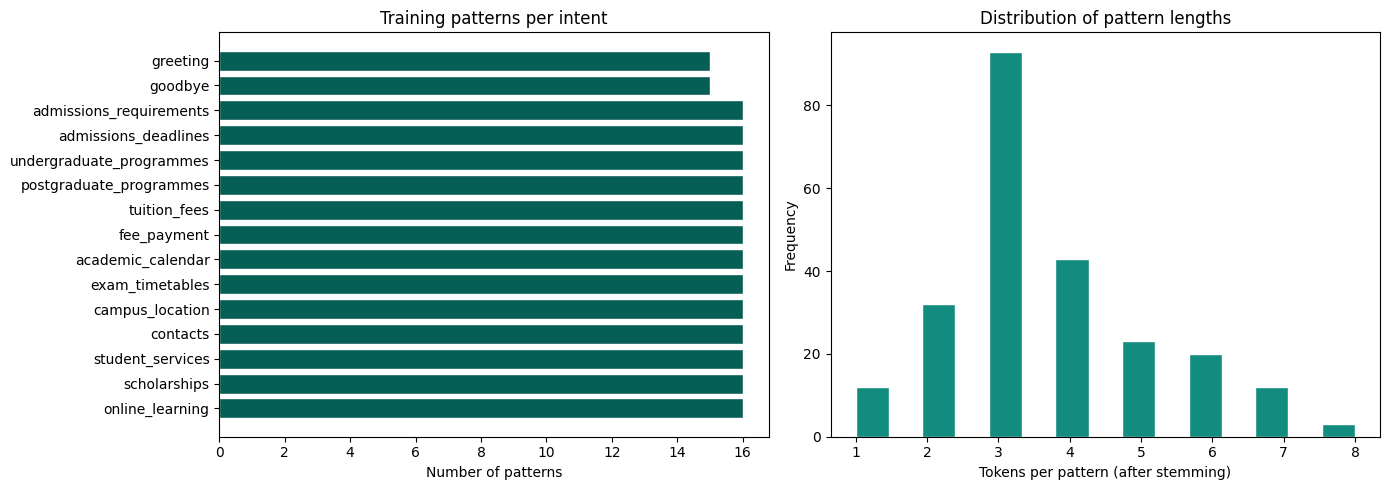

EDA charts saved as eda_patterns.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 5.1 Patterns per intent
tag_counts = {}
for _, tag in documents:
    tag_counts[tag] = tag_counts.get(tag, 0) + 1

axes[0].barh(list(tag_counts.keys()), list(tag_counts.values()),
             color="#075E54", edgecolor="white")
axes[0].set_xlabel("Number of patterns")
axes[0].set_title("Training patterns per intent")
axes[0].invert_yaxis()

# 5.2 Pattern length distribution
lengths = [len(tokens) for tokens, _ in documents]
axes[1].hist(lengths, bins=15, color="#128C7E", edgecolor="white")
axes[1].set_xlabel("Tokens per pattern (after stemming)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of pattern lengths")

plt.tight_layout()
plt.savefig("eda_patterns.png", dpi=100, bbox_inches="tight")
plt.show()
print("EDA charts saved as eda_patterns.png")


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all       # keep class proportions in both sets
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Feature dimension: {X_train.shape[1]} (vocabulary size)")


Training samples : 190
Test samples     : 48
Feature dimension: 219 (vocabulary size)


In [13]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    verbose=False,
)

mlp_model.fit(X_train, y_train)
print(f"Training complete. Iterations run: {mlp_model.n_iter_}")
print(f"Best validation score  : {mlp_model.best_validation_score_:.4f}")


Training complete. Iterations run: 78
Best validation score  : 0.7368


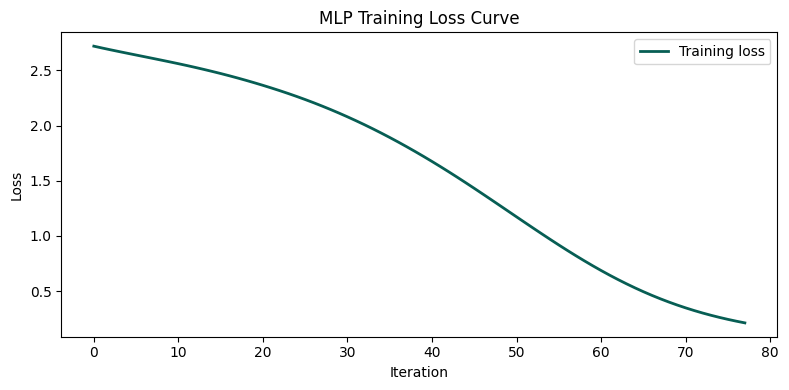

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_model.loss_curve_, color="#075E54", linewidth=2, label="Training loss")
if mlp_model.validation_fraction:
    pass  # validation score not tracked as a curve in sklearn MLP
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=100, bbox_inches="tight")
plt.show()


In [15]:
y_pred = mlp_model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {acc:.4f}  ({acc*100:.1f}%)")
print()
print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[classes[i] for i in sorted(set(y_all))],
    zero_division=0
))


Test accuracy: 0.6250  (62.5%)

Classification Report:
                          precision    recall  f1-score   support

       academic_calendar       0.75      1.00      0.86         3
    admissions_deadlines       0.50      1.00      0.67         3
 admissions_requirements       0.67      0.67      0.67         3
         campus_location       0.50      1.00      0.67         4
                contacts       0.50      0.67      0.57         3
         exam_timetables       1.00      0.67      0.80         3
             fee_payment       0.40      0.67      0.50         3
                 goodbye       1.00      1.00      1.00         3
                greeting       1.00      0.67      0.80         3
         online_learning       0.00      0.00      0.00         4
 postgraduate_programmes       0.50      0.33      0.40         3
            scholarships       0.50      0.33      0.40         3
        student_services       1.00      0.75      0.86         4
            tuition_

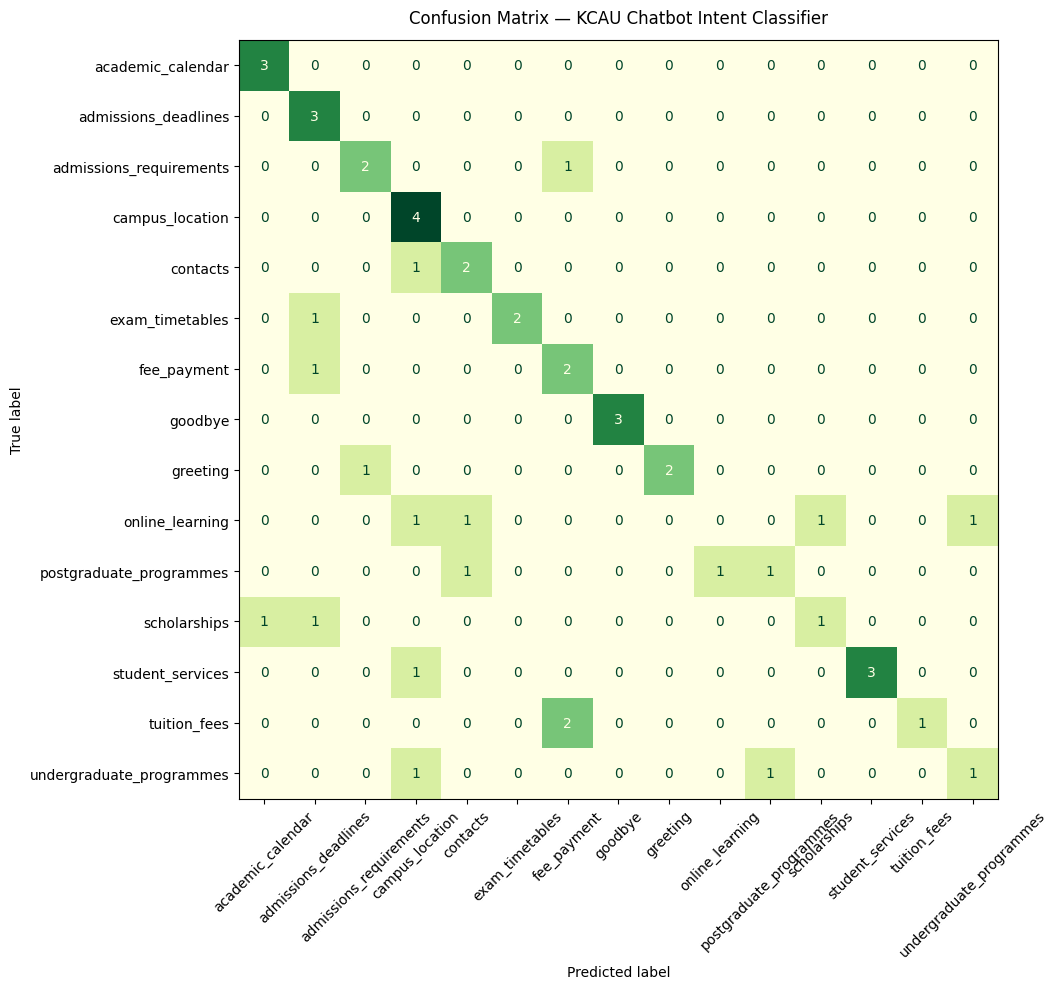

Confusion matrix saved as confusion_matrix.png


In [16]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[classes[i] for i in sorted(set(y_all))]
)
disp.plot(ax=ax, colorbar=False, cmap="YlGn",
          xticks_rotation=45)
ax.set_title("Confusion Matrix — KCAU Chatbot Intent Classifier", pad=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100, bbox_inches="tight")
plt.show()
print("Confusion matrix saved as confusion_matrix.png")


In [17]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=5.0)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_acc   = accuracy_score(y_test, lr_preds)

print(f"MLPClassifier accuracy       : {acc*100:.1f}%")
print(f"LogisticRegression accuracy  : {lr_acc*100:.1f}%")
print()
print("→ We will use MLPClassifier as the production model." if acc >= lr_acc
      else "→ We will use LogisticRegression as the production model.")

# Select the best model
best_model = mlp_model if acc >= lr_acc else lr_model
best_name  = "MLPClassifier" if acc >= lr_acc else "LogisticRegression"
print(f"   Selected: {best_name}")


MLPClassifier accuracy       : 62.5%
LogisticRegression accuracy  : 75.0%

→ We will use LogisticRegression as the production model.
   Selected: LogisticRegression


In [18]:
CONFIDENCE_THRESHOLD = 0.60

def predict_intent(text: str, model, vocab: list, intent_classes: list) -> tuple:
    """
    Preprocess text and predict intent.
    Returns (tag, confidence).
    """
    tokens = tokenize_and_stem(text)
    bow    = bag_of_words(tokens, vocab).reshape(1, -1)

    if hasattr(model, "predict_proba"):
        proba      = model.predict_proba(bow)[0]
        idx        = int(np.argmax(proba))
        confidence = float(proba[idx])
        tag        = intent_classes[idx]
    else:
        tag        = model.predict(bow)[0]
        confidence = 1.0
    return tag, confidence

def get_response(tag: str, data: dict) -> str:
    """Pick a random response for the predicted intent tag."""
    for intent in data["intents"]:
        if intent["tag"] == tag:
            return random.choice(intent["responses"])
    return "I'm not sure about that. Please contact KCAU at info@kcau.ac.ke."

# Test the full pipeline with sample queries
test_queries = [
    "What grades do I need to join KCAU?",
    "How do I pay fees using M-Pesa?",
    "When is the next intake?",
    "Does KCAU offer an MBA?",
    "Where is the university located?",
    "How much does BCom cost per semester?",
    "Can I study online at KCAU?",
    "Do you have HELB loans?",
]

print(f"{'Query':<45} {'Predicted intent':<30} {'Confidence':>10}")
print("-" * 90)
for q in test_queries:
    tag, conf = predict_intent(q, best_model, vocabulary, classes)
    flag = "" if conf >= CONFIDENCE_THRESHOLD else "⚠ below threshold"
    print(f"{q:<45} {tag:<30} {conf:>10.3f}  {flag}")


Query                                         Predicted intent               Confidence
------------------------------------------------------------------------------------------
What grades do I need to join KCAU?           admissions_requirements             0.950  
How do I pay fees using M-Pesa?               fee_payment                         0.812  
When is the next intake?                      admissions_deadlines                0.775  
Does KCAU offer an MBA?                       undergraduate_programmes            0.227  ⚠ below threshold
Where is the university located?              campus_location                     0.861  
How much does BCom cost per semester?         tuition_fees                        0.987  
Can I study online at KCAU?                   online_learning                     0.938  
Do you have HELB loans?                       scholarships                        0.413  ⚠ below threshold


In [19]:
joblib.dump(best_model, "chatbot_model.pkl")
joblib.dump(vocabulary,  "words.pkl")
joblib.dump(classes,     "classes.pkl")

# Verify files were written
for fname in ("chatbot_model.pkl", "words.pkl", "classes.pkl"):
    size = os.path.getsize(fname)
    print(f"  Saved {fname:<25}  ({size:,} bytes) ✓")

print("\nAll artefacts saved. You can now run chatbot_app.py.")


  Saved chatbot_model.pkl          (27,375 bytes) ✓
  Saved words.pkl                  (1,770 bytes) ✓
  Saved classes.pkl                (287 bytes) ✓

All artefacts saved. You can now run chatbot_app.py.


In [20]:
# Run this cell for a quick text-only chat demo (no GUI)
print("KCAU Student Assistant — text demo (type 'quit' to exit)\n")
while True:
    try:
        user_input = input("You: ").strip()
    except (EOFError, KeyboardInterrupt):
        break
    if user_input.lower() in ("quit", "exit", "bye"):
        print("Bot: Goodbye! Good luck with your studies.")
        break
    if not user_input:
        continue
    tag, conf = predict_intent(user_input, best_model, vocabulary, classes)
    if conf < CONFIDENCE_THRESHOLD:
        reply = "I'm not sure about that. Please contact KCAU at info@kcau.ac.ke."
    else:
        reply = get_response(tag, intents_data)
    print(f"Bot [{tag}, {conf:.2f}]: {reply}\n")


KCAU Student Assistant — text demo (type 'quit' to exit)

You: quit
Bot: Goodbye! Good luck with your studies.
